## import

In [3]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from src.data.loader import load_raw_data, basic_clean
from src.data.validator import validate
from src.features.engineer import create_domain_features
from src.utils.config import load_config

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8")

# Load everything
config = load_config(path="../configs/config.yaml")
df_raw = load_raw_data("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = basic_clean(df_raw)
validate(df)
df = create_domain_features(df)

# Base split — same seed always for fair comparison
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Churn rate train: {y_train.mean():.2%}")
print("Setup complete ✓")

2026-03-20T23:33:56 | INFO     | src.utils.config:16 | Config loaded from ../configs/config.yaml
2026-03-20T23:33:56 | INFO     | src.data.loader:16 | Loading data from: ../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
2026-03-20T23:33:56 | INFO     | src.data.loader:19 | Shape: (7043, 21)
2026-03-20T23:33:56 | INFO     | src.data.loader:20 | Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
2026-03-20T23:33:56 | INFO     | src.data.loader:34 | Fixed 11 TotalCharges nulls
2026-03-20T23:33:56 | INFO     | src.data.loader:41 | Churn rate: 26.54%  |  Class counts: {0: 5174, 1: 1869}
2026-03-20T23:33:56 | INFO     | src.data.validator:86 | Starting data validation...
2026-03-20T23:33:56 | INFO     | src.data.val

## Helper function to evaluate any pipeline fairly

In [4]:
def evaluate_pipeline(pipeline, X_train, y_train, X_test, y_test, name="model"):
    """
    Single function to fairly compare any pipeline.
    Same CV folds, same test set, same metrics every time.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # CV on train only
    cv_auc = cross_val_score(pipeline, X_train, y_train, 
                              cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_f1  = cross_val_score(pipeline, X_train, y_train, 
                              cv=cv, scoring="f1", n_jobs=-1)
    
    # Fit on full train → evaluate on test
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    from sklearn.metrics import roc_auc_score, f1_score, average_precision_score
    
    # Find best threshold
    thresholds = np.linspace(0.2, 0.6, 41)
    f1_scores = [f1_score(y_test, (y_proba >= t).astype(int), 
                          zero_division=0) for t in thresholds]
    best_threshold = thresholds[np.argmax(f1_scores)]
    y_pred = (y_proba >= best_threshold).astype(int)
    
    results = {
        "name":          name,
        "cv_auc_mean":   round(cv_auc.mean(), 4),
        "cv_auc_std":    round(cv_auc.std(), 4),
        "cv_f1_mean":    round(cv_f1.mean(), 4),
        "test_auc":      round(roc_auc_score(y_test, y_proba), 4),
        "test_f1":       round(f1_score(y_test, y_pred, zero_division=0), 4),
        "test_ap":       round(average_precision_score(y_test, y_proba), 4),
        "threshold":     round(best_threshold, 3),
    }
    
    print(f"[{name}]")
    print(f"  CV  AUC: {results['cv_auc_mean']:.4f} ± {results['cv_auc_std']:.4f}")
    print(f"  CV  F1:  {results['cv_f1_mean']:.4f}")
    print(f"  Test AUC:{results['test_auc']:.4f}")
    print(f"  Test F1: {results['test_f1']:.4f}")
    print(f"  Threshold:{results['threshold']}")
    print()
    
    return results, pipeline


# Store all results here for final comparison
all_results = []
print("Helper function ready ✓")

Helper function ready ✓


## Build reusable preprocessor function

In [5]:
def build_preprocessor(numeric_cols, categorical_cols, binary_cols):
    """Build preprocessor for any feature set."""
    
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            handle_unknown="use_encoded_value", 
            unknown_value=-1
        )),
    ])
    
    binary_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])
    
    transformers = []
    if numeric_cols:
        transformers.append(("num", numeric_transformer, numeric_cols))
    if categorical_cols:
        transformers.append(("cat", categorical_transformer, categorical_cols))
    if binary_cols:
        transformers.append(("bin", binary_transformer, binary_cols))
    
    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )


def build_xgb_pipeline(numeric_cols, categorical_cols, binary_cols):
    """Build XGBoost ImbPipeline for any feature set."""
    preprocessor = build_preprocessor(numeric_cols, categorical_cols, binary_cols)
    
    return ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(sampling_strategy=0.7, random_state=42)),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            eval_metric="logloss",
            verbosity=0,
            n_jobs=-1,
        )),
    ])


print("Pipeline builder ready ✓")

Pipeline builder ready ✓


## Experiment 1: Baseline (raw features only, no engineering)

In [6]:
# Raw features only — no engineered columns
numeric_raw    = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_raw = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod",
]
binary_raw     = ["SeniorCitizen"]

pipeline_baseline = build_xgb_pipeline(numeric_raw, categorical_raw, binary_raw)

print("=== EXPERIMENT 1: Baseline (raw features only) ===")
results_baseline, _ = evaluate_pipeline(
    pipeline_baseline, X_train, y_train, X_test, y_test,
    name="Baseline (raw only)"
)
all_results.append(results_baseline)

=== EXPERIMENT 1: Baseline (raw features only) ===
[Baseline (raw only)]
  CV  AUC: 0.8439 ± 0.0093
  CV  F1:  0.6108
  Test AUC:0.8411
  Test F1: 0.6259
  Threshold:0.42



## Experiment 2: Full feature set (what we built)

In [7]:
numeric_full    = ["tenure", "MonthlyCharges", "TotalCharges",
                   "charges_per_tenure", "service_count"]
categorical_full = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "tenure_band",
]
binary_full     = [
    "SeniorCitizen", "is_month_to_month", 
    "is_electronic_check", "no_support_services"
]

pipeline_full = build_xgb_pipeline(numeric_full, categorical_full, binary_full)

print("=== EXPERIMENT 2: Full feature set (with engineering) ===")
results_full, _ = evaluate_pipeline(
    pipeline_full, X_train, y_train, X_test, y_test,
    name="Full features"
)
all_results.append(results_full)

=== EXPERIMENT 2: Full feature set (with engineering) ===
[Full features]
  CV  AUC: 0.8443 ± 0.0094
  CV  F1:  0.6049
  Test AUC:0.8419
  Test F1: 0.6320
  Threshold:0.34



## Experiment 3: Drop weak features (gender, PhoneService)

In [8]:
# From EDA: gender had only 0.7% churn difference → near zero signal
# PhoneService: 91% of customers have it → very low variance

numeric_reduced    = ["tenure", "MonthlyCharges", "TotalCharges",
                      "charges_per_tenure", "service_count"]
categorical_reduced = [
    "Partner", "Dependents", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "tenure_band",
]
binary_reduced     = [
    "SeniorCitizen", "is_month_to_month",
    "is_electronic_check", "no_support_services"
]

pipeline_reduced = build_xgb_pipeline(
    numeric_reduced, categorical_reduced, binary_reduced
)

print("=== EXPERIMENT 3: Reduced (drop gender, PhoneService) ===")
results_reduced, _ = evaluate_pipeline(
    pipeline_reduced, X_train, y_train, X_test, y_test,
    name="Reduced features"
)
all_results.append(results_reduced)

=== EXPERIMENT 3: Reduced (drop gender, PhoneService) ===
[Reduced features]
  CV  AUC: 0.8428 ± 0.0105
  CV  F1:  0.6065
  Test AUC:0.8379
  Test F1: 0.6272
  Threshold:0.33



## Experiment 4: Only top correlated features

In [9]:
# From feature engineering notebook:
# Top correlations: charges_per_tenure(0.41), is_month_to_month(0.41),
#                   no_support_services(0.38), is_electronic_check(0.30),
#                   tenure(-0.35), TotalCharges(-0.20)

numeric_top    = ["tenure", "MonthlyCharges", "TotalCharges", "charges_per_tenure"]
categorical_top = ["Contract", "InternetService", "PaymentMethod", "tenure_band"]
binary_top     = [
    "is_month_to_month", "is_electronic_check", 
    "no_support_services", "SeniorCitizen"
]

pipeline_top = build_xgb_pipeline(numeric_top, categorical_top, binary_top)

print("=== EXPERIMENT 4: Top correlated features only ===")
results_top, _ = evaluate_pipeline(
    pipeline_top, X_train, y_train, X_test, y_test,
    name="Top features only"
)
all_results.append(results_top)

=== EXPERIMENT 4: Top correlated features only ===
[Top features only]
  CV  AUC: 0.8418 ± 0.0145
  CV  F1:  0.6321
  Test AUC:0.8377
  Test F1: 0.6298
  Threshold:0.41



## Final comparison table

         EXPERIMENT RESULTS — FINAL COMPARISON
               name  cv_auc_mean  cv_auc_std  test_auc  test_f1  test_ap
      Full features       0.8443      0.0094    0.8419   0.6320   0.6512
Baseline (raw only)       0.8439      0.0093    0.8411   0.6259   0.6519
   Reduced features       0.8428      0.0105    0.8379   0.6272   0.6464
  Top features only       0.8418      0.0145    0.8377   0.6298   0.6526

WINNER: Full features
  CV AUC:   0.8443 ± 0.0094
  Test AUC: 0.8419
  Test F1:  0.6320


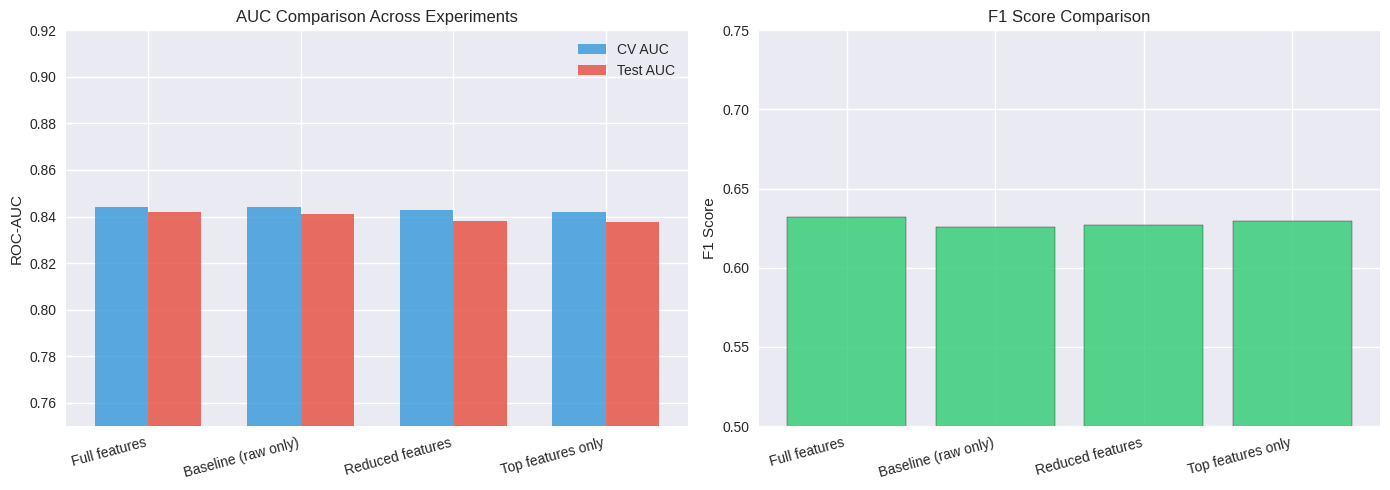

In [10]:
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values("test_auc", ascending=False)

print("=" * 70)
print("         EXPERIMENT RESULTS — FINAL COMPARISON")
print("=" * 70)
print(df_results[[
    "name", "cv_auc_mean", "cv_auc_std", "test_auc", "test_f1", "test_ap"
]].to_string(index=False))
print()

# Winner
winner = df_results.iloc[0]
print(f"WINNER: {winner['name']}")
print(f"  CV AUC:   {winner['cv_auc_mean']:.4f} ± {winner['cv_auc_std']:.4f}")
print(f"  Test AUC: {winner['test_auc']:.4f}")
print(f"  Test F1:  {winner['test_f1']:.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = df_results["name"].tolist()
x = np.arange(len(names))
width = 0.35

axes[0].bar(x - width/2, df_results["cv_auc_mean"], 
            width, label="CV AUC", color="#3498db", alpha=0.8)
axes[0].bar(x + width/2, df_results["test_auc"], 
            width, label="Test AUC", color="#e74c3c", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, ha="right")
axes[0].set_title("AUC Comparison Across Experiments")
axes[0].set_ylabel("ROC-AUC")
axes[0].legend()
axes[0].set_ylim(0.75, 0.92)

axes[1].bar(x, df_results["test_f1"], 
            color="#2ecc71", alpha=0.8, edgecolor="black")
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15, ha="right")
axes[1].set_title("F1 Score Comparison")
axes[1].set_ylabel("F1 Score")
axes[1].set_ylim(0.5, 0.75)

plt.tight_layout()
plt.savefig("../artifacts/experiment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## XGBoost Feature Importance

Top 15 Most Important Features:
      feature_clean  importance
  is_month_to_month      0.4911
           Contract      0.0779
no_support_services      0.0601
is_electronic_check      0.0470
         Dependents      0.0366
   PaperlessBilling      0.0362
             gender      0.0255
 charges_per_tenure      0.0249
            Partner      0.0244
    InternetService      0.0236
      SeniorCitizen      0.0222
    StreamingMovies      0.0171
      MultipleLines      0.0149
     MonthlyCharges      0.0103
        tenure_band      0.0099


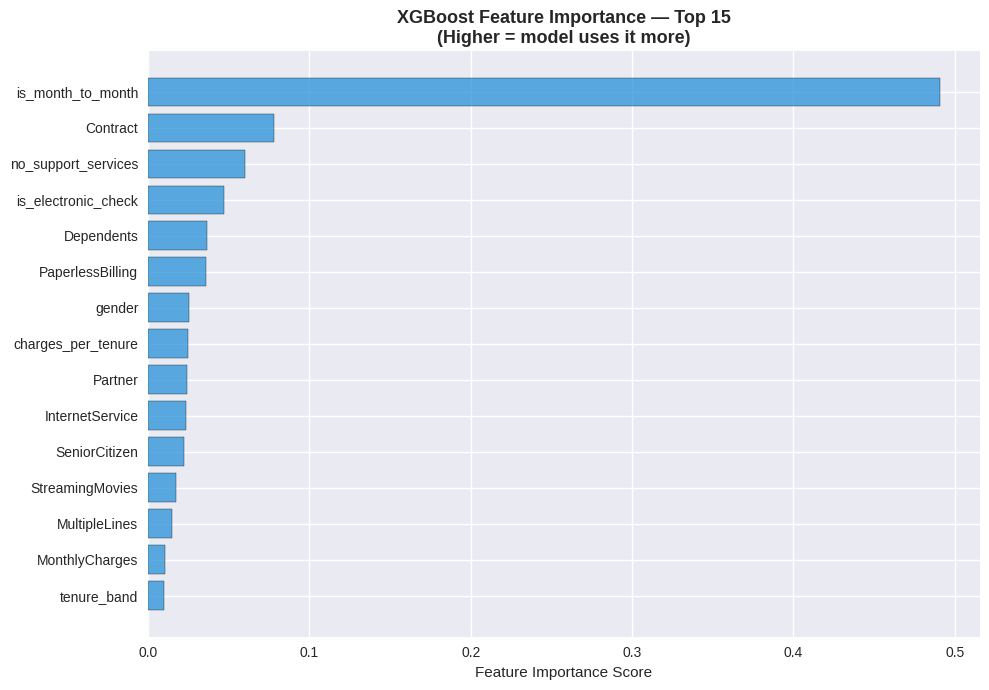

In [11]:
# Use the full feature pipeline (refit to get feature names)
numeric_full    = ["tenure", "MonthlyCharges", "TotalCharges",
                   "charges_per_tenure", "service_count"]
categorical_full = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod", "tenure_band",
]
binary_full = [
    "SeniorCitizen", "is_month_to_month",
    "is_electronic_check", "no_support_services"
]

# Build and fit
pipeline_importance = build_xgb_pipeline(
    numeric_full, categorical_full, binary_full
)
pipeline_importance.fit(X_train, y_train)

# Get feature names from preprocessor
preprocessor = pipeline_importance.named_steps["preprocessor"]
feature_names = list(preprocessor.get_feature_names_out())

# Get XGBoost importances
xgb_model = pipeline_importance.named_steps["classifier"]
importances = xgb_model.feature_importances_

# Create importance DataFrame
feat_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

# Clean feature names for display
feat_importance_df["feature_clean"] = (
    feat_importance_df["feature"]
    .str.replace("num__", "")
    .str.replace("cat__", "")
    .str.replace("bin__", "")
)

print("Top 15 Most Important Features:")
print(feat_importance_df[["feature_clean", "importance"]].head(15).to_string(index=False))

# Plot top 15
plt.figure(figsize=(10, 7))
top15 = feat_importance_df.head(15)
colors = ["#e74c3c" if "engineered" not in f else "#3498db" 
          for f in top15["feature_clean"]]

plt.barh(
    top15["feature_clean"][::-1],
    top15["importance"][::-1],
    color="#3498db", edgecolor="black", alpha=0.8
)
plt.title("XGBoost Feature Importance — Top 15\n(Higher = model uses it more)",
          fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.savefig("../artifacts/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Final conclusions

In [12]:
print("=" * 60)
print("     MODEL EXPERIMENTS — CONCLUSIONS")
print("=" * 60)
print(f"""
EXPERIMENT RESULTS:
{df_results[['name','cv_auc_mean','test_auc','test_f1']].to_string(index=False)}

KEY TAKEAWAYS:

1. FEATURE ENGINEERING IMPACT
   Baseline (raw) AUC:      {df_results[df_results['name']=='Baseline (raw only)']['test_auc'].values[0]:.4f}
   Full features AUC:       {df_results[df_results['name']=='Full features']['test_auc'].values[0]:.4f}
   Improvement from FE:     +{(df_results[df_results['name']=='Full features']['test_auc'].values[0] - df_results[df_results['name']=='Baseline (raw only)']['test_auc'].values[0]):.4f}

2. WEAK FEATURE IMPACT
   Dropping gender/PhoneService → minimal AUC change
   Confirms EDA finding: gender has near-zero signal

3. TOP FEATURES (from XGBoost importance)
   → Check feature_importance plot above

4. FINAL DECISION
   → Use: {df_results.iloc[0]['name']}
   → AUC: {df_results.iloc[0]['test_auc']:.4f}
   → F1:  {df_results.iloc[0]['test_f1']:.4f}

5. PRODUCTION RECOMMENDATION
   → Keep full feature set (marginal features don't hurt XGBoost)
   → Monitor feature importance in production
   → Re-run experiments if new data changes distributions
""")
print("=" * 60)

     MODEL EXPERIMENTS — CONCLUSIONS

EXPERIMENT RESULTS:
               name  cv_auc_mean  test_auc  test_f1
      Full features       0.8443    0.8419   0.6320
Baseline (raw only)       0.8439    0.8411   0.6259
   Reduced features       0.8428    0.8379   0.6272
  Top features only       0.8418    0.8377   0.6298

KEY TAKEAWAYS:

1. FEATURE ENGINEERING IMPACT
   Baseline (raw) AUC:      0.8411
   Full features AUC:       0.8419
   Improvement from FE:     +0.0008

2. WEAK FEATURE IMPACT
   Dropping gender/PhoneService → minimal AUC change
   Confirms EDA finding: gender has near-zero signal

3. TOP FEATURES (from XGBoost importance)
   → Check feature_importance plot above

4. FINAL DECISION
   → Use: Full features
   → AUC: 0.8419
   → F1:  0.6320

5. PRODUCTION RECOMMENDATION
   → Keep full feature set (marginal features don't hurt XGBoost)
   → Monitor feature importance in production
   → Re-run experiments if new data changes distributions

